Mahbub da paper Fig 8 

Running omega = 1.0
Number of Poincare points = 50100
Running omega = 2.5
Number of Poincare points = 50100
Running omega = 90.0
Number of Poincare points = 50100


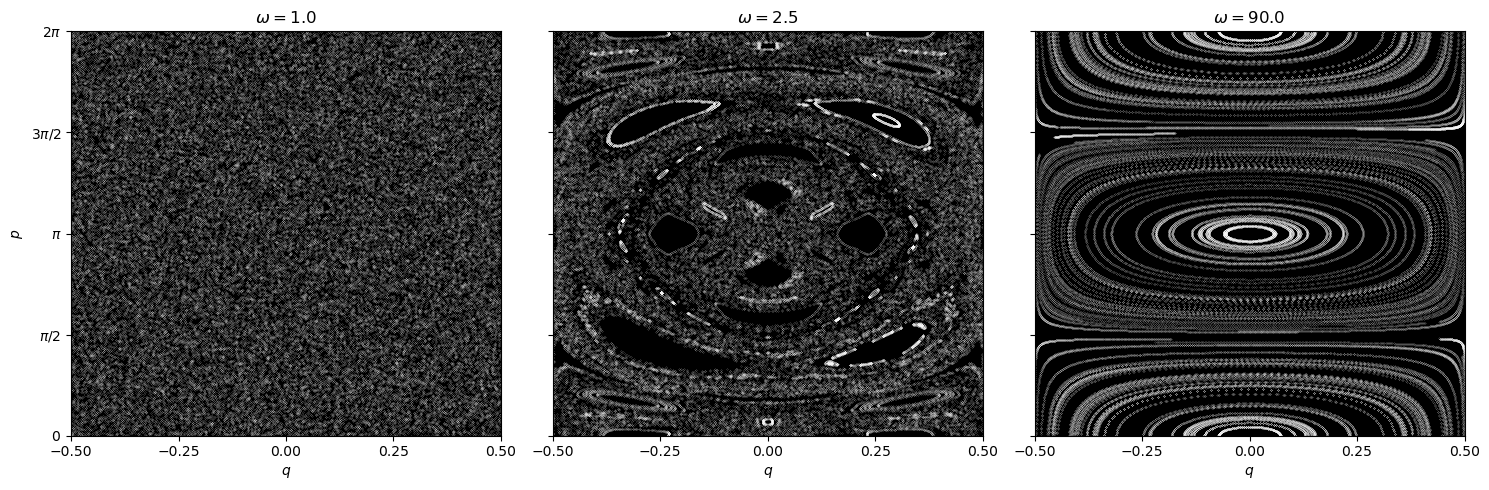

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import jn_zeros

# Parameters

eta = jn_zeros(0, 1)[0]
h0 = 0.0
omega_values = [1.0, 2.5, 90.0]

# Number of initial conditions
n_initial = 100

# Number of drive periods
n_periods = 500

# Reproducible random initial conditions
rng = np.random.default_rng(12345)

# Classical equations of motion

def classical_equations(t, y, omega, h_drive, h0):
    
    q, p = y

    # Time-dependent transverse field
    h_t = h_drive * np.cos(omega * t) + h0

    # Avoid numerical problems exactly at q = +/- 1/2
    root = np.sqrt(max(1.0 - 4.0 * q**2, 1e-14))
    dqdt = h_t * root * np.sin(p)
    dpdt = 4.0 * q * (1.0 - h_t * np.cos(p) / root)

    return [dqdt, dpdt]

# Generate initial conditions
# q must lie inside [-1/2, 1/2]
# Stay slightly away from the boundaries because Eq. (35)
# contains 1/sqrt(1 - 4q^2).

q_initial = rng.uniform(-0.499, 0.499, n_initial)

# p is an angular variable
p_initial = rng.uniform(0.0, 2.0 * np.pi, n_initial)

initial_conditions = np.column_stack((q_initial, p_initial))

# Calculate Poincare surface of section

def poincare_section(omega):
    
    # eta = 4h/omega
    # Therefore:
    h_drive = eta * omega / 4.0

    # Drive period
    T = 2.0 * np.pi / omega

    # Stroboscopic times:
    # t = nT
    t_strobe = np.arange(n_periods + 1) * T

    q_points = []
    p_points = []

    for q0, p0 in initial_conditions:

        sol = solve_ivp(classical_equations, (0.0, n_periods * T), [q0, p0], args=(omega, h_drive, h0), method="DOP853", t_eval=t_strobe, rtol=1e-9, atol=1e-11, max_step=T / 20.0)

        q = sol.y[0]
        p = sol.y[1]
        # Bring p back to [0, 2pi)
        p = np.mod(p, 2.0 * np.pi)
        q_points.append(q)
        p_points.append(p)

    q_points = np.concatenate(q_points)
    p_points = np.concatenate(p_points)

    return q_points, p_points


# ============================================================
# Calculate all three frequencies
# ============================================================

results = {}

for omega in omega_values:

    print(f"Running omega = {omega}")
    q_points, p_points = poincare_section(omega)
    results[omega] = (q_points, p_points)
    print(f"Number of Poincare points = {len(q_points)}")

# Plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, omega in zip(axes, omega_values):

    q_points, p_points = results[omega]

    ax.scatter(q_points, p_points, s=0.05, color="white", marker=".")
    ax.set_facecolor("black")
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([-0.5, -0.25, 0.0, 0.25, 0.5])
    ax.set_ylim(0.0, 2.0 * np.pi)
    ax.set_yticks([0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi])
    ax.set_xlabel(r"$q$")
    ax.set_yticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_title(rf"$\omega={omega}$")

axes[0].set_ylabel(r"$p$")

plt.tight_layout()
plt.show()

DMBL Engine 

eta = 2.404825557695773
h   = 1.503015973559858

Omega1 = 2.5
Omega2 = 2.0
Using common period T = 4*pi
 initial condition 0/100
 initial condition 20/100
 initial condition 40/100
 initial condition 60/100
 initial condition 80/100
Number of Poincare points = 50100

Omega1 = 2.5
Omega2 = 2.8284271247461903
Incommensurate frequencies.
Using T1 = 2*pi/Omega1 for stroboscopic sampling.
 initial condition 0/100
 initial condition 20/100
 initial condition 40/100
 initial condition 60/100
 initial condition 80/100
Number of Poincare points = 50100


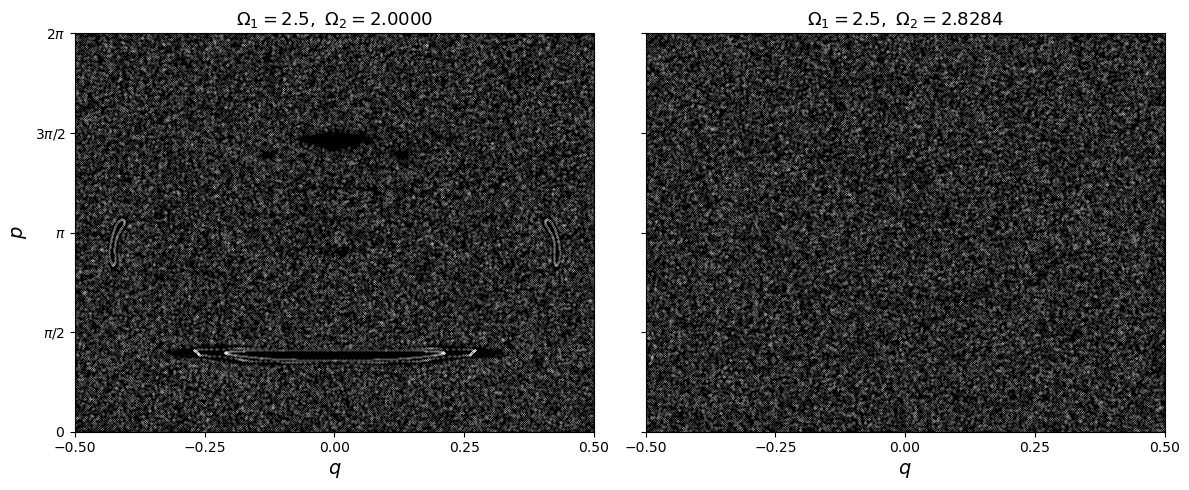

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import jn_zeros

# Parameters

eta = jn_zeros(0, 1)[0]

# h1 = h2 = h
#
# We use the same freezing condition as the paper:
#
#       4h / Omega1 = eta

Omega1 = 2.5
h = eta * Omega1 / 4.0
h1 = h
h2 = h
print("eta =", eta)
print("h   =", h)

# Two frequency pairs

frequency_pairs = [(2.5, 2.0), (2.5, 2.0 * np.sqrt(2.0))]

# Number of initial conditions

n_initial = 100

# Number of sampling periods
n_periods = 500



# Reproducible initial conditions

rng = np.random.default_rng(12345)

q_initial = rng.uniform(-0.499, 0.499, n_initial)

p_initial = rng.uniform(0.0, 2.0 * np.pi, n_initial)

initial_conditions = np.column_stack((q_initial, p_initial))

# Classical equations of motion


def classical_equations(t, y, h1, h2, Omega1, Omega2):

    q, p = y

    # Time-dependent fields
    
    h1_t = h1 * np.cos(Omega1 * t)
    h2_t = h2 * np.cos(Omega2 * t)   
    
    root = np.sqrt(max(1.0 - 4.0 * q**2, 1e-14))
    dqdt = root * (h1_t * np.sin(p) - h2_t * np.cos(p))   
    dpdt = (4.0 * q - (4.0 * q / root) * (h1_t * np.cos(p) + h2_t * np.sin(p)))

    return [dqdt, dpdt]



# Poincare section

def poincare_section(Omega1, Omega2, common_period=None):
   
    if common_period is not None:

        T = common_period

    else:

        # For the incommensurate case use the period of
        # the first drive as a stroboscopic sampling time.

        T = 2.0 * np.pi / Omega1

  
    # Stroboscopic times
   
    t_strobe = np.arange(n_periods + 1) * T

    q_points = []
    p_points = []

    # --------------------------------------------------------
    # Evolve every initial condition
    # --------------------------------------------------------

    for i, (q0, p0) in enumerate(initial_conditions):

        if i % 20 == 0:

            print(f" initial condition "f"{i}/{n_initial}")

        sol = solve_ivp(classical_equations, (0.0, n_periods * T),[q0, p0], args=(h1, h2, Omega1, Omega2), method="DOP853", t_eval=t_strobe, rtol=1e-9, atol=1e-11, max_step=T / 20.0)
        q = sol.y[0]
        p = sol.y[1]
        
        # Periodicity of p
       
        p = np.mod(p, 2.0 * np.pi)
        q_points.append(q)
        p_points.append(p)
    
    # Convert lists to arrays
   
    q_points = np.concatenate(q_points)
    p_points = np.concatenate(p_points)

    return q_points, p_points

# Calculate the two phase-space distributions
# ============================================================

results = []

for Omega1, Omega2 in frequency_pairs:

    print()
    print("=" * 60)
    print(f"Omega1 = {Omega1}")
    print(f"Omega2 = {Omega2}")
    print("=" * 60)
   
    # Determine common period
    

    if np.isclose(Omega2, 2.0):

        # Omega1 = 2.5 = 5/2
        # Omega2 = 2
        #
        # Common period = 4*pi

        common_period = 4.0 * np.pi

        print("Using common period T = 4*pi")

    else:

        # Irrational frequency ratio
        common_period = None

        print("Incommensurate frequencies.")

        print("Using T1 = 2*pi/Omega1 " "for stroboscopic sampling.")

    q_points, p_points = poincare_section(Omega1, Omega2, common_period)

    results.append((Omega1, Omega2, q_points, p_points))

    print("Number of Poincare points =", len(q_points))


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)


for ax, result in zip( axes, results):

    Omega1, Omega2, q_points, p_points = result
    ax.scatter(q_points, p_points, s=0.05, color="white", marker=".")
    ax.set_facecolor("black")

    # --------------------------------------------------------
    # q axis
    # --------------------------------------------------------

    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([-0.5, -0.25, 0.0, 0.25, 0.5])
    
    # p axis
    
    ax.set_ylim(0.0, 2.0 * np.pi)
    ax.set_yticks([0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlabel(r"$q$", fontsize=14)
    ax.set_title(rf"$\Omega_1={Omega1},\ "rf"\Omega_2={Omega2:.4f}$", fontsize=13)

axes[0].set_ylabel(r"$p$", fontsize=14)
plt.tight_layout()
plt.show()